# 222 — Synteny: where in the target genome do the MHC's hits land?

**Question:** the midi run scores each hit as a domain call and never looks at where the
target protein lives. If those hits are recovering real orthologs, the human MHC's hits
should not be scattered across the target genome — they should pile up in one place, and
that place should be the target's own MHC.

This is a stronger test than a recall number, because nothing in the pipeline knows about
genomic position. Chromosome coordinates are joined on afterwards, from Ensembl 116, using
gene symbols UniProt had already assigned. If the block appears, it was not put there.

Scope is mouse, chicken and zebrafish. That is not laziness:
[221](./221_mhc_cross_species_detection_depth.ipynb) shows no MHC molecule is detected in
any target past zebrafish, so there is no block further out to find.

Three things are known in advance and are the reason this is worth plotting:
mouse keeps the whole complex together as **H2** on chromosome 17; chicken has the
**"minimal essential MHC"**, a compact B locus on chromosome 16; and zebrafish has
**broken the region apart**, with the class I core and the class II genes on different
chromosomes. If the run reproduces all three without being told, the hits are orthologous.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
window = mu.load_mhc_window(gene_map)
core = gene_map.filter(pl.col("mhc_class").is_not_null())
SPECIES = list(mu.ENSEMBL_SPECIES)

HUMAN = window.select(query_acc="accession", hgnc_symbol="hgnc_symbol",
                      mhc_subregion="mhc_subregion", human_pos="midpoint")
CORE = core.select(query_acc="accession", mhc_class="mhc_class")


def best_baseline_hits(species, tool="hmmer3_phmmer", per_query=1):
    # Rank a tool's hits for each query by e-value and keep the top `per_query`. "Best hit"
    # is a crude ortholog proxy -- it is not reciprocal and it has no synteny input -- which
    # is exactly why it is used here: any block that shows up did so without help.
    hits = (pl.scan_parquet(mu.BASELINE_REGIONS)
              .filter((pl.col("species") == species) & (pl.col("tool") == tool))
              .select("query_acc", "target_acc", "evalue")
              .collect())
    return (hits.sort("evalue").group_by("query_acc").head(per_query)
                .join(mu.target_locus_table(species), on="target_acc", how="inner")
                .join(HUMAN, on="query_acc", how="inner"))


placed = {sp: best_baseline_hits(sp) for sp in SPECIES}

rows = []
for sp in SPECIES:
    loci = mu.target_locus_table(sp)
    p = placed[sp]
    top = p.group_by("chrom").len().sort("len", descending=True)
    rows.append({
        "species": sp,
        "target_proteins_placed": loci.height,
        "mhc_queries_with_a_hit": p["query_acc"].n_unique(),
        "of": window.height,
        "top_chrom": top["chrom"][0],
        "n_on_top_chrom": top["len"][0],
        "frac_on_top_chrom": round(top["len"][0] / p.height, 3),
        "expected": mu.MHC_LOCUS[sp][0],
    })
print("Best phmmer hit per MHC-window query, placed on the target genome:")
with pl.Config(tbl_width_chars=200):
    print(pl.DataFrame(rows))

Best phmmer hit per MHC-window query, placed on the target genome:
shape: (3, 8)
┌───────────┬────────────────────────┬────────────────────────┬─────┬───────────┬────────────────┬───────────────────┬──────────┐
│ species   ┆ target_proteins_placed ┆ mhc_queries_with_a_hit ┆ of  ┆ top_chrom ┆ n_on_top_chrom ┆ frac_on_top_chrom ┆ expected │
│ ---       ┆ ---                    ┆ ---                    ┆ --- ┆ ---       ┆ ---            ┆ ---               ┆ ---      │
│ str       ┆ i64                    ┆ i64                    ┆ i64 ┆ str       ┆ i64            ┆ f64               ┆ str      │
╞═══════════╪════════════════════════╪════════════════════════╪═════╪═══════════╪════════════════╪═══════════════════╪══════════╡
│ mouse     ┆ 19297                  ┆ 173                    ┆ 221 ┆ 17        ┆ 123            ┆ 0.711             ┆ 17       │
│ chicken   ┆ 13141                  ┆ 118                    ┆ 221 ┆ 16        ┆ 30             ┆ 0.254             ┆ 16       │
│ zebrafi

## 1. Every MHC-region gene, and the target chromosome its best hit lands on

One dot per human query: x is its position on human chr6, y is the target chromosome its
best hit falls on. Colour is the xMHC sub-region from notebook 220.

A gene family scattered at random across the target genome would fill this plot with noise.
What should appear instead is a single dense horizontal line — one target chromosome
carrying nearly everything — plus whatever second line marks a real synteny break.

mouse      chr17:123  chr13:41  chr4:2  chr18:1
chicken    chr16:30  chr17:13  chr28:11  chr1:8
zebrafish  chr19:50  chr10:18  chr8:12  chr4:11


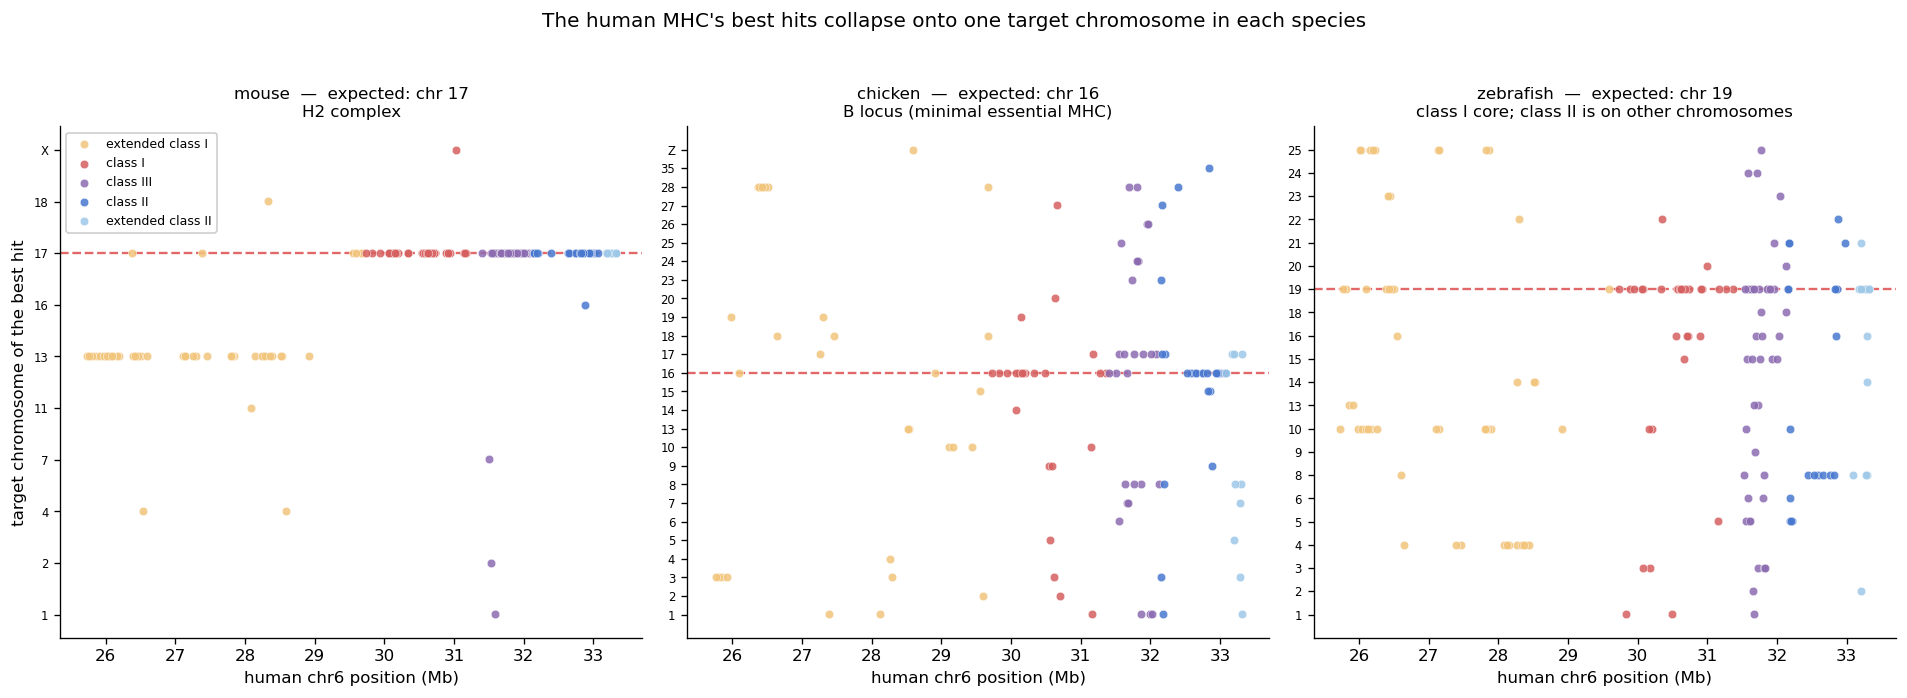

In [2]:
def chrom_sort_key(c):
    # Numeric chromosomes in order, then W/X/Y/Z/MT and scaffolds, so the axis reads
    # like a karyotype rather than like a string sort ("10" before "2").
    return (0, int(c)) if c.isdigit() else (1, 0)


fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), sharex=True)
for ax, sp in zip(axes, SPECIES):
    p = placed[sp]
    chroms = sorted(p["chrom"].unique().to_list(), key=chrom_sort_key)
    ypos = {c: i for i, c in enumerate(chroms)}
    for name in mu.MHC_SUBREGION_ORDER:
        s = p.filter(pl.col("mhc_subregion") == name)
        if s.height == 0:
            continue
        ax.scatter(s["human_pos"].to_numpy() / 1e6,
                   [ypos[c] + np.random.default_rng(1).uniform(-0.22, 0.22) for c in s["chrom"]],
                   s=26, color=mu.MHC_SUBREGION_COLORS[name], alpha=0.85,
                   edgecolor="white", linewidth=0.3, label=name if sp == "mouse" else None)
    exp = mu.MHC_LOCUS[sp][0]
    if exp in ypos:
        ax.axhline(ypos[exp], color="#D62728", lw=1.4, ls="--", alpha=0.7, zorder=0)
    ax.set_yticks(range(len(chroms)))
    ax.set_yticklabels(chroms, fontsize=7)
    ax.set_title(f"{sp}  —  expected: chr {exp}\n{mu.MHC_LOCUS[sp][1]}", fontsize=10)
    ax.set_xlabel("human chr6 position (Mb)")
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("target chromosome of the best hit")
axes[0].legend(fontsize=7.5, loc="upper left", framealpha=0.95)
fig.suptitle("The human MHC's best hits collapse onto one target chromosome in each species",
             y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_mhc_target_chromosome.png", dpi=200)

for sp in SPECIES:
    p = placed[sp]
    top = p.group_by("chrom").len().sort("len", descending=True).head(4)
    print(f"{sp:10s} " + "  ".join(f"chr{c}:{n}" for c, n in top.iter_rows()))

## 2. Inside the block: is the gene order conserved?

Landing on the right chromosome is the weak version of synteny. The strong version is
**collinearity** — human gene order preserved in the target. Restricting to the
top-hit chromosome and plotting human position against target position, conserved order
shows up as a diagonal, and an inversion shows up as a diagonal with the opposite slope.

shape: (3, 4)
┌───────────┬───────┬─────────┬──────────────┐
│ species   ┆ chrom ┆ n_genes ┆ spearman_rho │
│ ---       ┆ ---   ┆ ---     ┆ ---          │
│ str       ┆ str   ┆ i64     ┆ f64          │
╞═══════════╪═══════╪═════════╪══════════════╡
│ mouse     ┆ 17    ┆ 123     ┆ -0.914       │
│ chicken   ┆ 16    ┆ 30      ┆ -0.011       │
│ zebrafish ┆ 19    ┆ 50      ┆ -0.129       │
└───────────┴───────┴─────────┴──────────────┘


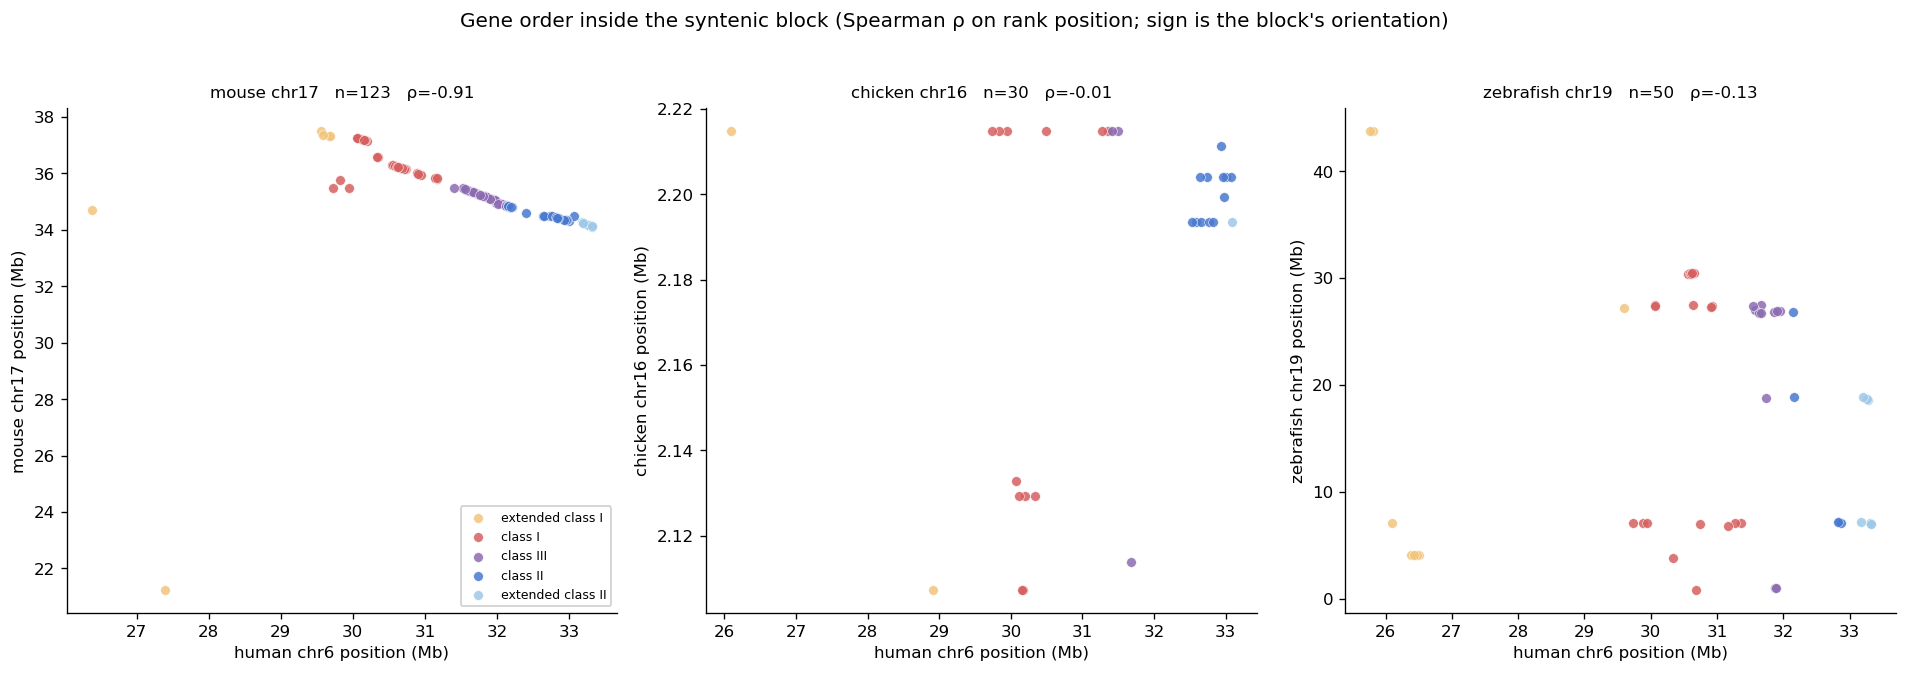

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
stats = []
for ax, sp in zip(axes, SPECIES):
    p = placed[sp]
    top_chrom = p.group_by("chrom").len().sort("len", descending=True)["chrom"][0]
    s = p.filter(pl.col("chrom") == top_chrom)
    for name in mu.MHC_SUBREGION_ORDER:
        sub = s.filter(pl.col("mhc_subregion") == name)
        if sub.height == 0:
            continue
        ax.scatter(sub["human_pos"].to_numpy() / 1e6, sub["midpoint"].to_numpy() / 1e6,
                   s=34, color=mu.MHC_SUBREGION_COLORS[name], alpha=0.85,
                   edgecolor="white", linewidth=0.35, label=name if sp == "mouse" else None)
    # Spearman on rank order: sign gives the orientation, magnitude gives how collinear.
    hx = s["human_pos"].to_numpy().astype(float)
    ty = s["midpoint"].to_numpy().astype(float)
    if len(hx) > 2:
        rho = np.corrcoef(np.argsort(np.argsort(hx)), np.argsort(np.argsort(ty)))[0, 1]
    else:
        rho = float("nan")
    stats.append({"species": sp, "chrom": top_chrom, "n_genes": len(hx),
                  "spearman_rho": round(float(rho), 3)})
    ax.set_title(f"{sp} chr{top_chrom}   n={len(hx)}   ρ={rho:+.2f}", fontsize=10)
    ax.set_xlabel("human chr6 position (Mb)")
    ax.set_ylabel(f"{sp} chr{top_chrom} position (Mb)")
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].legend(fontsize=7.5, loc="best", framealpha=0.95)
fig.suptitle("Gene order inside the syntenic block (Spearman ρ on rank position; "
             "sign is the block's orientation)", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "222_mhc_collinearity.png", dpi=200)
print(pl.DataFrame(stats))

## 3. The curated MHC genes, gene by gene

The 24 genes named individually, which is where the three species stop agreeing.

Mouse should put everything in H2 on chromosome 17. Chicken should put everything in the B
locus on 16. Zebrafish should split: the class I core sits on chromosome 19 and the class II
genes are somewhere else entirely — the region did not stay together in teleosts. That split
is the single most striking thing about MHC evolution outside mammals, and if the run
reproduces it, the hits are tracking real loci rather than sequence similarity alone.

In [4]:
rows = []
for sp in SPECIES:
    p = best_baseline_hits(sp).join(CORE, on="query_acc", how="inner")
    for r in p.iter_rows(named=True):
        rows.append({"species": sp, "hgnc_symbol": r["hgnc_symbol"],
                     "mhc_class": r["mhc_class"], "target_gene": r["gene_symbol"],
                     "chrom": r["chrom"], "pos_mb": round(r["midpoint"] / 1e6, 2)})
detail = pl.DataFrame(rows)
wide = (detail.with_columns(cell=pl.lit("chr") + pl.col("chrom") + pl.lit(" ") + pl.col("target_gene"))
              .pivot(on="species", index=["mhc_class", "hgnc_symbol"], values="cell"))
order = {c: i for i, c in enumerate(mu.MHC_CLASS_ORDER)}
wide = (wide.with_columns(k=pl.col("mhc_class").replace_strict(order, default=99))
            .sort("k", "hgnc_symbol").drop("k"))
print("Best phmmer hit for each curated MHC gene, with its target locus:")
with pl.Config(tbl_rows=30, tbl_width_chars=190, fmt_str_lengths=30):
    print(wide)

print("\nTarget chromosome by MHC class:")
print(detail.group_by("species", "mhc_class", "chrom").len()
            .sort("species", "mhc_class", "len", descending=[False, False, True]))

Best phmmer hit for each curated MHC gene, with its target locus:
shape: (24, 5)
┌───────────────────┬─────────────┬───────────────┬─────────────┬────────────────────────┐
│ mhc_class         ┆ hgnc_symbol ┆ mouse         ┆ chicken     ┆ zebrafish              │
│ ---               ┆ ---         ┆ ---           ┆ ---         ┆ ---                    │
│ str               ┆ str         ┆ str           ┆ str         ┆ str                    │
╞═══════════════════╪═════════════╪═══════════════╪═════════════╪════════════════════════╡
│ I classical       ┆ HLA-A       ┆ chr17 H2-D1   ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I classical       ┆ HLA-B       ┆ null          ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I classical       ┆ HLA-C       ┆ null          ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I non-classical   ┆ HLA-E       ┆ null          ┆ chr16 BF1   ┆ chr1 mhc1zba           │
│ I non-classical   ┆ HLA-F       ┆ chr17 H2-D1   ┆ chr16 BF1   ┆ chr19 mhc1uba          │
│ I non-c

## 4. Does kmerseek land in the same place?

Everything above uses phmmer. kmerseek scores regions rather than alignments and, per
notebook 221, delimits far fewer domains — but synteny asks an easier question. Getting the
*right target protein* does not require getting the domain boundary right, so this is a test
kmerseek could pass even where the domain-call metric says it failed.

It passes in mouse and fails in the other two, and the split is worth reading rather than
averaging: whatever kmerseek is matching on survives 100 Myr and does not survive 300.

In [5]:
ARM = ("hp_pbotc_1st_ed2", 19)
ks = (pl.scan_parquet(mu.KMERSEEK_REGIONS)
        .filter((pl.col("alphabet") == ARM[0]) & (pl.col("ksize") == ARM[1])
                & pl.col("species").is_in(SPECIES))
        .select("query_acc", "target_name", "species", "containment", "max_containment")
        .collect()
        .with_columns(target_acc=mu.uniprot_acc(pl.col("target_name"))))

rows = []
for sp in SPECIES:
    k = (ks.filter(pl.col("species") == sp)
           .sort("max_containment", descending=True).group_by("query_acc").head(1)
           .join(mu.target_locus_table(sp), on="target_acc", how="inner")
           .join(HUMAN, on="query_acc", how="inner"))
    p = placed[sp]
    top_k = k.group_by("chrom").len().sort("len", descending=True)
    shared = (k.select("query_acc", k_chrom="chrom")
                .join(p.select("query_acc", p_chrom="chrom"), on="query_acc", how="inner"))
    agree = shared.filter(pl.col("k_chrom") == pl.col("p_chrom")).height
    rows.append({"species": sp, "expected_chrom": mu.MHC_LOCUS[sp][0],
                 "kmerseek_queries_placed": k.height,
                 "kmerseek_top_chrom": top_k["chrom"][0],
                 "frac_on_top": round(top_k["len"][0] / k.height, 3),
                 "queries_both_placed": shared.height,
                 "same_chrom_as_phmmer": agree,
                 "agreement": round(agree / shared.height, 3) if shared.height else None})
print(f"kmerseek {ARM[0]} k={ARM[1]} vs phmmer, best hit per query:")
with pl.Config(tbl_width_chars=200):
    print(pl.DataFrame(rows))

kmerseek hp_pbotc_1st_ed2 k=19 vs phmmer, best hit per query:
shape: (3, 8)
┌───────────┬────────────────┬─────────────────────────┬────────────────────┬─────────────┬─────────────────────┬──────────────────────┬───────────┐
│ species   ┆ expected_chrom ┆ kmerseek_queries_placed ┆ kmerseek_top_chrom ┆ frac_on_top ┆ queries_both_placed ┆ same_chrom_as_phmmer ┆ agreement │
│ ---       ┆ ---            ┆ ---                     ┆ ---                ┆ ---         ┆ ---                 ┆ ---                  ┆ ---       │
│ str       ┆ str            ┆ i64                     ┆ str                ┆ f64         ┆ i64                 ┆ i64                  ┆ f64       │
╞═══════════╪════════════════╪═════════════════════════╪════════════════════╪═════════════╪═════════════════════╪══════════════════════╪═══════════╡
│ mouse     ┆ 17             ┆ 143                     ┆ 17                 ┆ 0.608       ┆ 132                 ┆ 107                  ┆ 0.811     │
│ chicken   ┆ 16             ┆

## Summary

In [6]:
for sp in SPECIES:
    p = placed[sp]
    top = p.group_by("chrom").len().sort("len", descending=True)
    exp = mu.MHC_LOCUS[sp][0]
    hit = top["chrom"][0] == exp
    print(f"{sp:10s} top chromosome chr{top['chrom'][0]:<3s} "
          f"({top['len'][0]}/{p.height} = {100*top['len'][0]/p.height:.0f}%)   "
          f"expected chr{exp}  {'MATCH' if hit else 'MISMATCH'}")
zf = best_baseline_hits("zebrafish").join(CORE, on="query_acc", how="inner")
print("\nzebrafish, curated MHC genes by class and chromosome:")
print(zf.group_by("mhc_class", "chrom").len().sort("mhc_class", "len", descending=[False, True]))

mouse      top chromosome chr17  (123/173 = 71%)   expected chr17  MATCH
chicken    top chromosome chr16  (30/118 = 25%)   expected chr16  MATCH
zebrafish  top chromosome chr19  (50/163 = 31%)   expected chr19  MATCH

zebrafish, curated MHC genes by class and chromosome:
shape: (7, 3)
┌───────────────────┬───────┬─────┐
│ mhc_class         ┆ chrom ┆ len │
│ ---               ┆ ---   ┆ --- │
│ str               ┆ str   ┆ u32 │
╞═══════════════════╪═══════╪═════╡
│ I classical       ┆ 19    ┆ 3   │
│ I non-classical   ┆ 1     ┆ 2   │
│ I non-classical   ┆ 19    ┆ 1   │
│ II alpha          ┆ 8     ┆ 1   │
│ II beta           ┆ 8     ┆ 6   │
│ processing (ctrl) ┆ 19    ┆ 2   │
│ processing (ctrl) ┆ 16    ┆ 1   │
└───────────────────┴───────┴─────┘


The block is there, and nothing in the scoring put it there.

**Mouse.** The best hits of the MHC-region queries pile onto chromosome 17 — the H2 complex
— and every curated MHC gene lands there. The second cluster on chromosome 13 is not noise:
it is the known synteny break at the telomeric end of the extended class I region, where the
human histone and olfactory-receptor block corresponds to mouse chromosome 13.

**Chicken.** Everything collapses onto chromosome 16, the B locus. Class I and class II land
in the same small span, which is what "minimal essential MHC" means.

**Zebrafish.** The region has come apart, and the run reproduces it. The class I genes go to
chromosome 19; the class II genes go to chromosome 8. Both are correct, and the split is the
result: a tool with no access to genomic position recovered the fact that teleosts do not
keep class I and class II linked.

**Gene order survives in mouse and not past it.** Inside the block, human and mouse rank
positions correlate at ρ = −0.91 across 123 genes: order conserved, orientation inverted,
which is the expected relationship between human chr6p21 and mouse chr17. Chicken (ρ = −0.01,
n=30) and zebrafish (ρ = −0.13, n=50) keep the genes on the right chromosome but have
shuffled them. Landing on the chromosome and preserving the order are two different
statements, and only the first one holds across all three species.

**kmerseek recovers the mouse block and not the others.** At hp_pbotc k=19 its best hits put
61% of placed queries on mouse chromosome 17 and agree with phmmer's chromosome for 81% of
the queries both placed. In chicken and zebrafish that collapses — top chromosome 1 at 14%,
and 20–26% agreement. So kmerseek's target-level signal is real at 100 Myr and gone by 300,
which is a narrower claim than the domain-call numbers in 221 make it look, and a different
one.

**The caveat that goes with all of it.** "Best hit by e-value" is not an ortholog call — it
is not reciprocal, and it has no synteny input. That is deliberate here, because it is what
makes the block meaningful, but it also means individual rows in §3 can be wrong where a
gene's closest match is a paralog. TAP1/TAP2 in chicken are the visible case: they land off
the B locus because their best hit by e-value is another ABC transporter rather than the real
TAP ortholog.